In [25]:
%load_ext cudf.pandas
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

The cudf.pandas extension is already loaded. To reload it, use:
  %reload_ext cudf.pandas


In [26]:
# importing weather forcasting dataset

zip_path = tf.keras.utils.get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    fname="jena_climate_2009_2016.csv.zip",
    extract=True,
)

In [27]:
zip_path

'/root/.keras/datasets/jena_climate_2009_2016_extracted'

In [28]:
import os
csv_path = os.path.join(zip_path, "jena_climate_2009_2016.csv")

df = pd.read_csv(csv_path)
df.head()

,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [29]:
df.columns

Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)',
       'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)',
       'wd (deg)'],
      dtype='object')

In [30]:
column_mapping = {
    "Date Time": "date_time",
    "p (mbar)": "pressure",
    "T (degC)": "temperature",
    "Tpot (K)": "potential_temp",
    "Tdew (degC)": "dew_point",
    "rh (%)": "relative_humidity",
    "VPmax (mbar)": "max_vapor_pressure",
    "VPact (mbar)": "actual_vapor_pressure",
    "VPdef (mbar)": "vapor_pressure_deficit",
    "sh (g/kg)": "specific_humidity",
    "H2OC (mmol/mol)": "water_vapor_concentration",
    "rho (g/m**3)": "air_density",
    "wv (m/s)": "wind_speed",
    "max. wv (m/s)": "max_wind_speed",
    "wd (deg)": "wind_direction",
}

df.rename(columns=column_mapping, inplace=True)

with pd.option_context('display.max_columns',None):
    display(df.head())

,date_time,pressure,temperature,potential_temp,dew_point,relative_humidity,max_vapor_pressure,actual_vapor_pressure,vapor_pressure_deficit,specific_humidity,water_vapor_concentration,air_density,wind_speed,max_wind_speed,wind_direction
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [31]:
print(df.shape)

df.describe()

(420551, 15)


,pressure,temperature,potential_temp,dew_point,relative_humidity,max_vapor_pressure,actual_vapor_pressure,vapor_pressure_deficit,specific_humidity,water_vapor_concentration,air_density,wind_speed,max_wind_speed,wind_direction
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,1.702224,3.056555,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,65.446714,69.016932,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000


In [32]:
df['wind_speed'] = df['wind_speed'].replace(-9999.0, 0.0)
df['max_wind_speed'] = df['max_wind_speed'].replace(-9999.0, 0.0)

In [33]:
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 420551 entries, 0 to 420550
Data columns (total 15 columns):
 #   Column                     Non-Null Count   Dtype
---  ------                     --------------   -----
 0   date_time                  420551 non-null  object
 1   pressure                   420551 non-null  float64
 2   temperature                420551 non-null  float64
 3   potential_temp             420551 non-null  float64
 4   dew_point                  420551 non-null  float64
 5   relative_humidity          420551 non-null  float64
 6   max_vapor_pressure         420551 non-null  float64
 7   actual_vapor_pressure      420551 non-null  float64
 8   vapor_pressure_deficit     420551 non-null  float64
 9   specific_humidity          420551 non-null  float64
 10  water_vapor_concentration  420551 non-null  float64
 11  air_density                420551 non-null  float64
 12  wind_speed                 420551 non-null  float64
 13  max_wind_speed             42055

In [34]:
df['date_time'] = pd.to_datetime(df['date_time'], format='%d.%m.%Y %H:%M:%S')

In [35]:
df['date_time']

0        2009-01-01 00:10:00
1        2009-01-01 00:20:00
2        2009-01-01 00:30:00
3        2009-01-01 00:40:00
4        2009-01-01 00:50:00
                 ...        
420546   2016-12-31 23:20:00
420547   2016-12-31 23:30:00
420548   2016-12-31 23:40:00
420549   2016-12-31 23:50:00
420550   2017-01-01 00:00:00
Name: date_time, Length: 420551, dtype: datetime64[ns]

In [36]:
df

,date_time,pressure,temperature,potential_temp,dew_point,relative_humidity,max_vapor_pressure,actual_vapor_pressure,vapor_pressure_deficit,specific_humidity,water_vapor_concentration,air_density,wind_speed,max_wind_speed,wind_direction
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.30,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.40,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.90,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.20,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.10,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
420546,2016-12-31 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,2016-12-31 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,2016-12-31 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,2016-12-31 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8


In [37]:
df.isna().sum()

date_time                    0
pressure                     0
temperature                  0
potential_temp               0
dew_point                    0
relative_humidity            0
max_vapor_pressure           0
actual_vapor_pressure        0
vapor_pressure_deficit       0
specific_humidity            0
water_vapor_concentration    0
air_density                  0
wind_speed                   0
max_wind_speed               0
wind_direction               0
dtype: int64

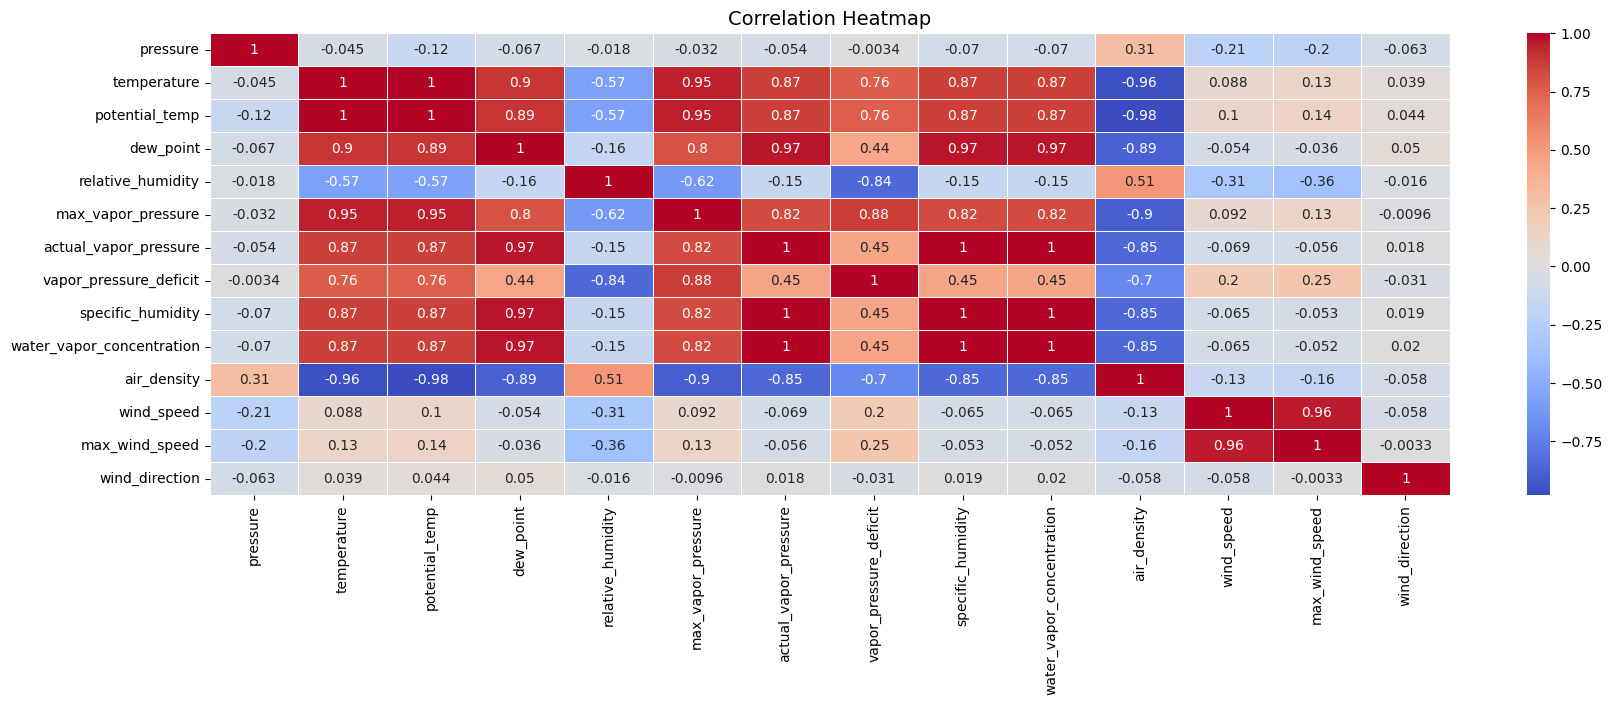

In [43]:
temp = df.drop(columns=['date_time'])
temp = temp.corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20,6))
sns.heatmap(np.array(temp), xticklabels=temp.columns, yticklabels=temp.columns, cmap='coolwarm', linewidth=0.5, annot=True)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()
